# Annual numbers for programs


**HOW TO USE THIS JUPYTER NOTEBOOK:** highlight the cell by clicking on it. You should see a green or blue box surround it. Then hold the Shift key and press Enter. You should see the highlight box move on to the next cell, and it will print or plot whatever the code says to do.
Try it here. Click on the gray text box below to highlight the cell, then hold Shift and press Enter.

In [1]:
print("Hello world!")

Hello world!


If it says **Hello world!** to you below the gray cell, it worked!

## Import statements, classes, and methods. 
Run these (Shift, Enter) then keep going. They shouldn't spit anything out at you. If they do, tell Abbie.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import ipywidgets as widgets
import traitlets
from IPython.display import display
from tkinter import Tk, filedialog

In [3]:
class SelectFilesButton(widgets.Button):
    """A file widget that leverages tkinter.filedialog."""

    def __init__(self):
        super(SelectFilesButton, self).__init__()
        # Add the selected_files trait
        self.add_traits(files=traitlets.traitlets.List())
        # Create the button.
        self.description = "Select Files"
        self.icon = "square-o"
        self.style.button_color = "orange"
        # Set on click behavior.
        self.on_click(self.select_files)

    @staticmethod
    def select_files(b):
        """Generate instance of tkinter.filedialog.

        Parameters
        ----------
        b : obj:
            An instance of ipywidgets.widgets.Button 
        """
        # Create Tk root
        root = Tk()
        # Hide the main window
        root.withdraw()
        # Raise the root to the top of all windows.
        root.call('wm', 'attributes', '.', '-topmost', True)
        # List of selected fileswill be set to b.value
        b.files = filedialog.askopenfilename(multiple=True)

        b.description = "Files Selected"
        b.icon = "check-square-o"
        b.style.button_color = "lightgreen"    

In [4]:
def clean_up_df(raw_df):
    """ 
    This method takes a dataframe with program information like Name, Location, Date, Time, Capacity, 
    and two rows for Attended, one with a number for 'Yes' and another with a number for 'No'
    """
    clean_df = pd.DataFrame(columns=('Name', 'Series', 'Location', 'Date', 'Time', 'Day', 
                                         'Capacity', 'Preregistered', 'Attended', 'Percentage'))
    clean_df['Name'] = raw_df['Name'].unique()
    for i in range(len(clean_df)):
        namemask = raw_df.where(raw_df['Name'] == clean_df['Name'][i])
        fvi = namemask.first_valid_index()
        clean_df.loc[i, 'Series'] = namemask['Series'][fvi]
        clean_df.loc[i, 'Location'] = namemask['Location'][fvi]
        clean_df.loc[i, 'Date'] = pd.to_datetime(namemask['Date'][fvi])
        clean_df.loc[i, 'Time'] = namemask['Time'][fvi]
        clean_df.loc[i, 'Capacity'] = namemask['Capacity'][fvi]
        yes_fvi = namemask.where(namemask['Attended'] == "Yes").first_valid_index()
        if yes_fvi == None:
            clean_df.loc[i,'Attended'] = 0
        else:
            clean_df.loc[i, 'Attended'] = namemask['Number'][yes_fvi]
        no_fvi = namemask.where(namemask['Attended'] == "No").first_valid_index()
        if no_fvi == None:
            clean_df.loc[i, 'Preregistered'] = clean_df['Attended'][i]
        else:
            clean_df.loc[i, 'Preregistered'] = clean_df['Attended'][i] + namemask['Number'][no_fvi]
                                                                                        
    clean_df['Percentage'] = clean_df['Attended'] / clean_df['Preregistered']
    clean_df.sort_values(by="Date", inplace=True)
    clean_df['Day'] = [j.strftime('%a') for j in clean_df['Date']]
    return clean_df

In [5]:
def convert_yesno_to_bool(yesno):
    """ This method converts 'yes' and 'no' in an Altru excel file to boolean values."""
    if yesno.casefold() == "yes".casefold():
        return True
    elif yesno.casefold() == "no".casefold():
        return False
    else:
        return np.nan

In [6]:
def get_ci90(df, groupbything, columnthing):
    """ This method gets the 90% confidence interval for errors on a distribution. 
    Need to use with errorbar=('ci', 90) in the plots!"""
    n = len(df)
    means = df.groupby(groupbything, observed=False)[columnthing].mean()
    print("Means:")
    print(means)
    stddevs = df.groupby(groupbything, observed=False)[columnthing].std()
    ci90 = 1.645 * (stddevs / np.sqrt(n))
    print("90% errors:")
    print(ci90)

## Run the cell below, then click the button to select your data file to load. 

The code expects an .xlsx data file made in Altru with the 'Program Query: Food Fight!' ad-hoc query. This file makes columns for the program name, program location, program date and time, participant capacity as specified in Altru, number of spaces still available, then two rows for each program: one with the number of pre-registrants who attended, and one with the number of pre-registrants who did not.

In [7]:
# button1 = SelectFilesButton()
# button1  # This will display the button in the context of Jupyter Notebook

Run this next cell to assign that file name to a variable and read in the excel file, then make a Pandas Dataframe called `programs` with the cleaned data. It will print basic information about the `programs` dataframe.

In [11]:
prefix = "FY25-all"
q_dir = "./%s/" % (prefix)

In [13]:
# program_xlsx_file = button1.files[0]
program_xlsx_file = "%s/%s_programs.xlsx" % (q_dir, prefix)
raw_program_data = pd.read_excel(program_xlsx_file, engine='openpyxl')
if len(raw_program_data) % 2 != 0:
    print("WARNING: There are an odd number of lines in the program query data file. Please check the file in Excel to ensure that each program is listed twice, once with 'No' and once with 'Yes'. If you're missing a 'Yes' line (because nobody attended), copy the 'No' line, change 'No' to 'Yes', and change 'Number' to 0, and save the changes.")
else:
    programs = clean_up_df(raw_program_data)
    print(programs.info())

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 4 to 23
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           24 non-null     object
 1   Series         24 non-null     object
 2   Location       24 non-null     object
 3   Date           24 non-null     object
 4   Time           24 non-null     object
 5   Day            24 non-null     object
 6   Capacity       24 non-null     object
 7   Preregistered  24 non-null     object
 8   Attended       24 non-null     object
 9   Percentage     24 non-null     object
dtypes: object(10)
memory usage: 2.1+ KB
None


If it's throwing an error, check the program query data file that each program has two lines, a line with "no" and a line with "yes". If you're missing a "yes" line (because nobody attended), copy the "no" line, change "no" to "yes", and change "number" to "0".

In [14]:
display(programs)

,Name,Series,Location,Date,Time,Day,Capacity,Preregistered,Attended,Percentage
4,A Midsummer Night's Disco,First Fridays FY 24-25,Beal Botanical Garden,2024-09-06 00:00:00,7:00 PM,Fri,1000.0,566.0,310.0,0.547703
11,Artist Talk and Welcome,MSUFCU Arts Power Up: Lopez Lopez,Kresge Art Center,2024-09-19 00:00:00,5:10 PM,Thu,100.0,43.0,15.0,0.348837
0,Empower the Future: 2024 Youth Summit on Polit...,2024 Smithsonian National Youth Summit.,Communication Arts and Sciences Building,2024-09-20 00:00:00,10:00 AM,Fri,150.0,101.0,87.0,0.861386
5,Whodunit? A Night of Mysteries with the MSU Mu...,First Fridays FY 24-25,Brody Square,2024-10-04 00:00:00,7:00 PM,Fri,500.0,294.0,141.0,0.479592
12,Artists in Dialogue and Opening Reception,MSUFCU Arts Power Up: Lopez Lopez,311 Abbot,2024-10-05 00:00:00,1:00 PM,Sat,140.0,62.0,34.0,0.548387
13,The Syntax of Science,MSUFCU Arts Power Up: Lopez Lopez,FRIB (Facility for Rare Isotope Beams),2024-10-24 00:00:00,5:10 PM,Thu,200.0,82.0,57.0,0.695122
1,Ignite Talks MSU 3,CoLab Studio,311 Abbot,2024-10-30 00:00:00,7:00 PM,Wed,145.0,144.0,91.0,0.631944
6,Spooky Soiree,First Fridays FY 24-25,311 Abbot,2024-11-01 00:00:00,7:00 PM,Fri,500.0,176.0,113.0,0.642045
10,Michigan African American Craft Legacy Project...,Michigan African American Craft Legacy Project,MSU Detroit Center,2024-11-07 00:00:00,6:00 PM,Thu,10.0,10.0,10.0,1.0
3,Indigenous Hip Hop: Frank Waln’s Journey of Mu...,Cultural Heritage Months FY24-25,Communication Arts and Sciences Building,2024-11-07 00:00:00,6:00 PM,Thu,200.0,111.0,47.0,0.423423


In [37]:
programs.sort_values(by='Date')

,Name,Series,Location,Date,Time,Day,Capacity,Preregistered,Attended,Percentage
4,A Midsummer Night's Disco,First Fridays,Beal,2024-09-06 00:00:00,7:00 PM,Fri,1000.0,566.0,310.0,0.547703
11,Artist Talk and Welcome,MSUFCU Arts Power Up: Lopez Lopez,Kresge,2024-09-19 00:00:00,5:10 PM,Thu,100.0,43.0,15.0,0.348837
0,Empower the Future: 2024 Youth Summit on Polit...,2024 Smithsonian National Youth Summit.,WKAR,2024-09-20 00:00:00,10:00 AM,Fri,150.0,101.0,87.0,0.861386
5,Whodunit? A Night of Mysteries with the MSU Mu...,First Fridays,Brody,2024-10-04 00:00:00,7:00 PM,Fri,500.0,294.0,141.0,0.479592
12,Artists in Dialogue and Opening Reception,MSUFCU Arts Power Up: Lopez Lopez,311 Abbot,2024-10-05 00:00:00,1:00 PM,Sat,140.0,62.0,34.0,0.548387
13,The Syntax of Science,MSUFCU Arts Power Up: Lopez Lopez,FRIB,2024-10-24 00:00:00,5:10 PM,Thu,200.0,82.0,57.0,0.695122
1,Ignite Talks MSU 3,CoLab Studio,311 Abbot,2024-10-30 00:00:00,7:00 PM,Wed,145.0,144.0,91.0,0.631944
6,Spooky Soiree,First Fridays,311 Abbot,2024-11-01 00:00:00,7:00 PM,Fri,500.0,176.0,113.0,0.642045
10,Michigan African American Craft Legacy Project...,Michigan African American Craft Legacy Project,MSU Detroit Center,2024-11-07 00:00:00,6:00 PM,Thu,10.0,10.0,10.0,1.0
3,Indigenous Hip Hop: Frank Waln’s Journey of Mu...,Cultural Heritage Months FY24-25,WKAR,2024-11-07 00:00:00,6:00 PM,Thu,200.0,111.0,47.0,0.423423


In [38]:
## Shortening program series names
nope_idx = programs['Name'].str.casefold().str.contains('cancelled|postponed'.casefold())
programs.loc[nope_idx, 'Percentage'] = np.nan 

In [40]:
for i in range(len(programs)):
    print("%s\t%s\t%d" % (programs.loc[i,'Date'].strftime("%-m/%-d/%y"), 
                          programs.loc[i, 'Name'], 
                          programs.loc[i, 'Attended']))

9/20/24	Empower the Future: 2024 Youth Summit on Politics and Activism	87
10/30/24	Ignite Talks MSU 3	91
2/26/25	Ignite Talks MSU 4	69
11/7/24	Indigenous Hip Hop: Frank Waln’s Journey of Music, Activism, and Resilience	47
9/6/24	A Midsummer Night's Disco	310
10/4/24	Whodunit? A Night of Mysteries with the MSU Museum	141
11/1/24	Spooky Soiree	113
1/17/25	Game on!	79
2/7/25	Techno Silent Disco	152
3/14/25	Pi(e) Night	90
11/7/24	Michigan African American Craft Legacy Project: Workshop #3	10
9/19/24	Artist Talk and Welcome	15
10/5/24	Artists in Dialogue and Opening Reception	34
10/24/24	The Syntax of Science	57
2/15/25	SciCurious? Explore MSU’s Science Collections	156
3/15/25	Techno Poetry Slam	43
3/20/25	Her Sound, Her City: Performance	97
3/20/25	Her Sound, Her City: Talk	52
3/27/25	Submerged Realities	29
4/3/25	Futurist Frequencies: A Conversation with Jeff Mills	68
4/11/25	John Collins of Underground Resistance: DJ Set	103
4/17/25	Carl Craig DJ Set: Techno Futures: Detroit's Afrofuturi

If you have cancelled or postponed programs (or other reasons why the attendance percentage would be Not a Number), filter those out of what's going to be plotted.

In [41]:
nan_idx = programs['Percentage'].isnull()
programs = programs.loc[~nan_idx]

If the program series is ongoing, filter out the ones that haven't happened yet.

In [42]:
display(programs['Name'])

4                             A Midsummer Night's Disco
11                              Artist Talk and Welcome
0     Empower the Future: 2024 Youth Summit on Polit...
5     Whodunit? A Night of Mysteries with the MSU Mu...
12            Artists in Dialogue and Opening Reception
13                                The Syntax of Science
1                                    Ignite Talks MSU 3
6                                         Spooky Soiree
10    Michigan African American Craft Legacy Project...
3     Indigenous Hip Hop: Frank Waln’s Journey of Mu...
7                                              Game on!
8                                   Techno Silent Disco
14        SciCurious? Explore MSU’s Science Collections
2                                    Ignite Talks MSU 4
9                                           Pi(e) Night
15                                   Techno Poetry Slam
16                     Her Sound, Her City: Performance
17                            Her Sound, Her Cit

## Let's get some basic numbers!

In [43]:
print("There were %d registrants and %d attendees." % (programs['Preregistered'].sum(), programs['Attended'].sum()))

There were 4059 registrants and 2154 attendees.


In [44]:
display(programs[['Name', 'Percentage', 'Attended']])

,Name,Percentage,Attended
4,A Midsummer Night's Disco,0.547703,310.0
11,Artist Talk and Welcome,0.348837,15.0
0,Empower the Future: 2024 Youth Summit on Polit...,0.861386,87.0
5,Whodunit? A Night of Mysteries with the MSU Mu...,0.479592,141.0
12,Artists in Dialogue and Opening Reception,0.548387,34.0
13,The Syntax of Science,0.695122,57.0
1,Ignite Talks MSU 3,0.631944,91.0
6,Spooky Soiree,0.642045,113.0
10,Michigan African American Craft Legacy Project...,1.0,10.0
3,Indigenous Hip Hop: Frank Waln’s Journey of Mu...,0.423423,47.0


In [45]:
programs['Series'] = pd.Categorical(programs['Series'], ordered=True)

Plot the attendance of programs as a function of time! (this only looks good for a whole exhibition or year)

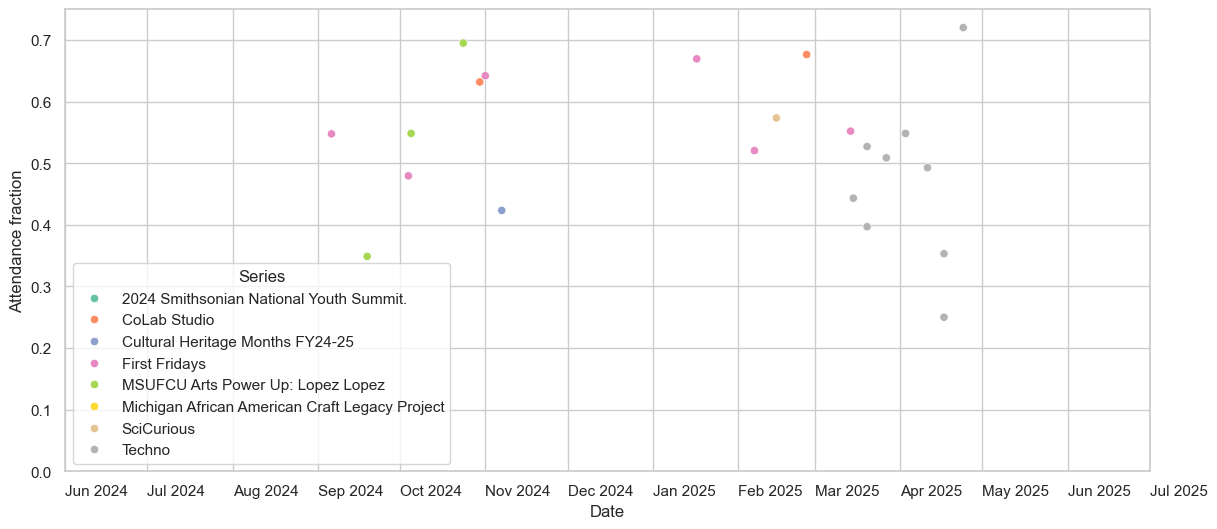

In [47]:
fig, ax = plt.subplots(figsize=(14,6))
fig = sns.scatterplot(data=programs.dropna(), x='Date', y='Percentage', hue='Series', palette="Set2")
x_dates = pd.date_range(start='6/2024', end='7/2025', freq='MS', inclusive='both')
ax.set_xticks(x_dates, labels=x_dates.strftime('%b %Y'), horizontalalignment='left')
datalabels = programs['Name']
# TODO: mouseover to read name?!?
ax.set(ylim=(0, 0.75), ylabel="Attendance fraction")
fig.figure.savefig(q_dir+"/program_attendance_timeline_scatter.png",bbox_inches='tight')
plt.show()

## Program type

In [48]:
print("Attendance fraction per program series:")
programs.groupby('Series', observed=False)['Percentage'].mean()


Attendance fraction per program series:


Series
2024 Smithsonian National Youth Summit.           0.861386
CoLab Studio                                      0.654208
Cultural Heritage Months FY24-25                  0.423423
First Fridays                                     0.568588
MSUFCU Arts Power Up: Lopez Lopez                 0.530782
Michigan African American Craft Legacy Project         1.0
SciCurious                                        0.573529
Techno                                            0.471189
Name: Percentage, dtype: object

## Program location

Rank the locations by number of programs held there.

In [50]:
loc_cats = programs['Location'].value_counts(ascending=False, dropna=True).index
programs['Location'] = pd.Categorical(programs['Location'], categories=loc_cats, ordered=True)

How was attendance of programs based on their location?

In [51]:
programs.groupby('Location', observed=False, dropna=True)['Percentage'].mean()

Location
311 Abbot             0.564803
WKAR                  0.498153
Beal                  0.547703
Kresge                0.348837
Brody                 0.479592
FRIB                  0.695122
MSU Detroit Center         1.0
NatSci                0.573529
Name: Percentage, dtype: object

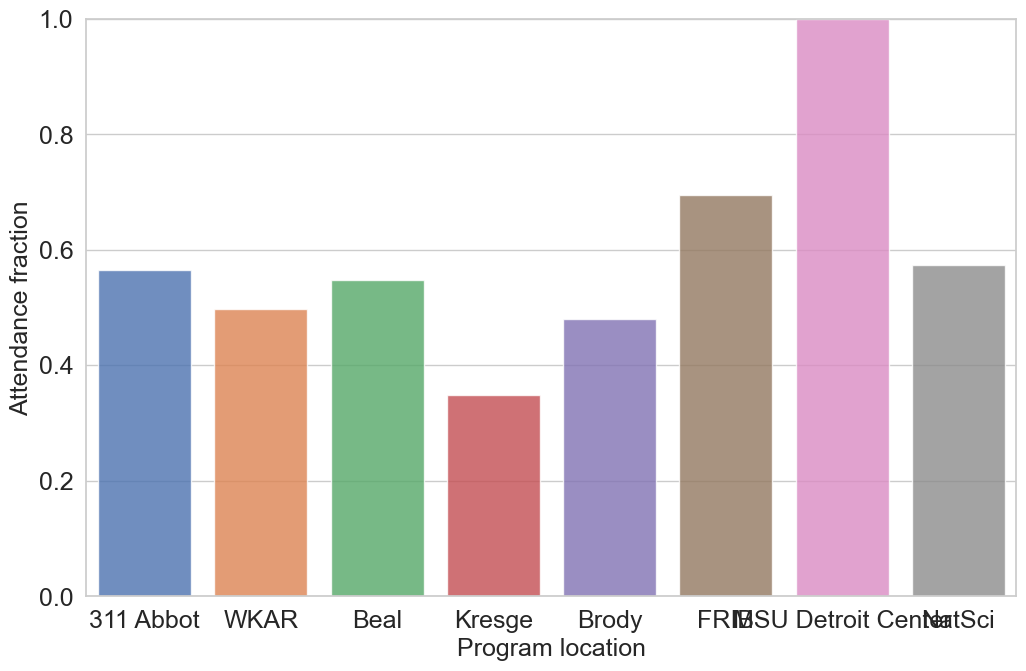

In [52]:
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette('deep')
fig = sns.barplot(data=programs, x='Location', y='Percentage', palette='deep', 
                  hue='Location', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="Program location", ylabel="Attendance fraction", ylim=(0,1))
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/program_location_bar.png", bbox_inches='tight')
plt.show()

# Program attendees

Now we can get nitty-gritty. Let's load in the data file with all the registrants for each program.

**VERY IMPORTANT NOTE:** You need to open the excel file and double-check that the non-MSU affiliation says "Not MSU" instaed of "None". Otherwise, having no MSU affiliation gets merged with the people for whom we don't have that information. If needed, do find-replace IN EXCEL to switch "None" to "Not MSU".

In [53]:
# button2 = SelectFilesButton()
# button2  # This will display the button in the context of Jupyter Notebook

In [54]:
# reg_xlsx_file = button2.files[0]
reg_xlsx_file = "%s/%s_registrants.xlsx" % (q_dir, prefix)

In [55]:
registrants = pd.read_excel(reg_xlsx_file, engine='openpyxl', converters={'Attended': convert_yesno_to_bool})
display(registrants.info())

# type_cats = ['Workshop', 'Conversation', 'Performance', 'Other']
# programs['Type'] = pd.Categorical(programs['Type'], categories=type_cats, ordered=True)

# Only keep the programs we used above, since we did some filtering before.
registrants = registrants[registrants['Program name'].isin(programs['Name'].unique().tolist())]

## Shortening location names
registrants['Program location'] = registrants['Program location'].replace("Beal Botanical Garden", "Beal")
registrants['Program location'] = registrants['Program location'].replace("Communication Arts and Sciences Building", "WKAR")
registrants['Program location'] = registrants['Program location'].replace("Kresge Art Center", "Kresge")    
registrants['Program location'] = registrants['Program location'].replace("MSU Main Library", "MSU Library")  
registrants['Program location'] = registrants['Program location'].replace("FRIB (Facility for Rare Isotope Beams)", "FRIB")  
registrants['Program location'] = registrants['Program location'].replace("Brody Square", "Brody")  
registrants['Program location'] = registrants['Program location'].replace("Natural Science Building", "NatSci")  
registrants['MSU affiliation'] = registrants['MSU affiliation'].fillna("N/A")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5449 entries, 0 to 5448
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Visitor name      5449 non-null   object
 1   Attended          5449 non-null   bool  
 2   MSU affiliation   4142 non-null   object
 3   ZIP code          3776 non-null   object
 4   Program name      5448 non-null   object
 5   Program location  5449 non-null   object
 6   Host name         3418 non-null   object
 7   Number of guests  5449 non-null   int64 
 8   Notes             54 non-null     object
 9   QUERYRECID        5449 non-null   object
dtypes: bool(1), int64(1), object(8)
memory usage: 388.6+ KB


None

In [57]:
series_cats = programs['Series'].unique()
registrants['Program series'] = pd.Categorical(np.empty(len(registrants)), categories=series_cats, ordered=True)
print(registrants['Program name'].unique())

['Techno Poetry Slam' "A Midsummer Night's Disco" 'Spooky Soiree'
 'Whodunit? A Night of Mysteries with the MSU Museum'
 'Techno Silent Disco' 'A Night at the Museum with the cadre'
 'SciCurious? Explore MSU’s Science Collections' 'Artist Talk and Welcome'
 'Artists in Dialogue and Opening Reception' 'Ignite Talks MSU 3'
 'Ignite Talks MSU 4' 'The Syntax of Science' 'Game on!'
 "Carl Craig DJ Set: Techno Futures: Detroit's Afrofuturist Groove"
 'Futurist Frequencies: A Conversation with Jeff Mills' 'Pi(e) Night'
 'Indigenous Hip Hop: Frank Waln’s Journey of Music, Activism, and Resilience'
 'John Collins of Underground Resistance: DJ Set'
 'Empower the Future: 2024 Youth Summit on Politics and Activism'
 'Her Sound, Her City: Talk'
 "Techno Futures: Detroit's Afrofuturist Groove"
 'Her Sound, Her City: Performance' 'Submerged Realities'
 'Michigan African American Craft Legacy Project: Workshop #3']


We can assign a preferred order to display the MSU affiliations.

In [58]:
affil_cats = ['Student', 'Faculty/Staff', 'Alum', 'Parent/Family', 'Not MSU', 'N/A']
registrants['MSU affiliation'] = pd.Categorical(registrants['MSU affiliation'], categories=affil_cats, ordered=True)

In [59]:
print(len(registrants))
print(sum(registrants['Attended']))

4059
2154


Remove Abbie and Brittany, since we sign up for every program to test the links and emails.

In [31]:
# notmeA_idx = ["Abbie Stevens".casefold() not in item.casefold() for item in registrants['Visitor name']]
# registrants = registrants.loc[notmeA_idx]
# notmeB_idx = ["Brittany Carter".casefold() not in item.casefold() for item in registrants['Visitor name']]
# registrants = registrants.loc[notmeB_idx]

Remove CoLab Studio, since that's our generic host for walk-ins. (I tried just removing its affiliation, but that threw errors down below with the `hosts` dataframe).

In [32]:
colab_idx = ["CoLab Studio".casefold() in item.casefold() for item in registrants['Visitor name']]
registrants.loc[colab_idx, 'MSU affiliation'] = np.nan

In [60]:
print(len(registrants))
print(sum(registrants['Attended']))

4059
2154


In [61]:
display(registrants.groupby('Program name', observed=False)['Attended'].sum())

Program name
A Midsummer Night's Disco                                                      310
A Night at the Museum with the cadre                                           139
Artist Talk and Welcome                                                         15
Artists in Dialogue and Opening Reception                                       34
Carl Craig DJ Set: Techno Futures: Detroit's Afrofuturist Groove               137
Empower the Future: 2024 Youth Summit on Politics and Activism                  87
Futurist Frequencies: A Conversation with Jeff Mills                            68
Game on!                                                                        79
Her Sound, Her City: Performance                                                97
Her Sound, Her City: Talk                                                       52
Ignite Talks MSU 3                                                              91
Ignite Talks MSU 4                                                        

In [35]:
sns.set_style('whitegrid')

In [96]:
# These were throwing errors because we had a some different punctuation in the name
registrants.loc[registrants['Program name'].str.contains("SciCurious"), 'Program name'] = "SciCurious"
registrants.loc[registrants['Program name'].str.contains("SciCurious"), 'Program series'] = "SciCurious"
registrants.loc[registrants['Program name'].str.contains("Pi* Night"), 'Program name'] = "Pie Night"
registrants['Program name'] = registrants['Program name'].replace("Whodunit? A Night of Mysteries with the MSU Museum", "Whodunit")
registrants['Program name'] = registrants['Program name'].replace("SciCurious?", "SciCurious")
registrants['Program name'] = registrants['Program name'].replace("Pi(e) Night", "Pie Night")
programs['Name'] = programs['Name'].replace("Whodunit? A Night of Mysteries with the MSU Museum", "Whodunit")
programs['Name'] = programs['Name'].replace("SciCurious? Explore MSU’s Science Collections", "SciCurious")
programs['Name'] = programs['Name'].replace("Pi(e) Night", "Pie Night")

display(registrants['Program name'])

0                                   Techno Poetry Slam
1                            A Midsummer Night's Disco
2                                        Spooky Soiree
3                                             Whodunit
4                                  Techno Silent Disco
                             ...                      
5442                         A Midsummer Night's Disco
5444                                          Whodunit
5445    John Collins of Underground Resistance: DJ Set
5446                         A Midsummer Night's Disco
5448                                         Pie Night
Name: Program name, Length: 4059, dtype: object

In [97]:
registrants['MSU affiliation'] = pd.Categorical(registrants['MSU affiliation'], categories=affil_cats, ordered=True)

for i in range(len(programs['Name'])):
    prog_loc = registrants['Program name'].str.contains(programs.loc[i, 'Name'], case=False)
    registrants.loc[prog_loc, 'Program series'] = programs.loc[i, 'Series']
    


/var/folders/56/pmp8wp79205_qtsg828g7bdc0000gq/T/ipykernel_16004/2772068062.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(fig.get_xticklabels(), rotation=345)


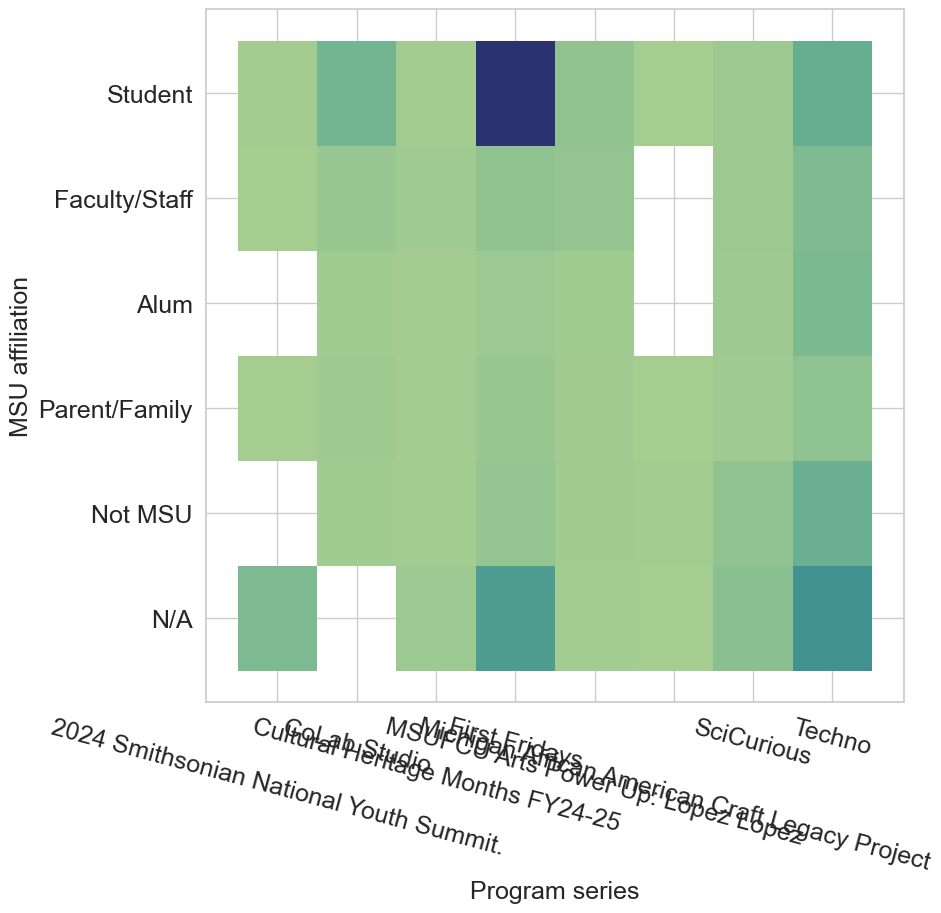

In [98]:
attendees = registrants.loc[registrants['Attended'] == True]

fig, ax = plt.subplots(figsize=(9,9))
fig = sns.histplot(attendees, x='Program series', y='MSU affiliation', cmap='crest')
fig.set_xticklabels(fig.get_xticklabels(), rotation=345)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
plt.show()

In [100]:
students_attended = attendees.loc[attendees['MSU affiliation'] == "N/A"]
for i in range(len(programs['Name'])):
    prog_loc = students_attended['Program name'].str.contains(programs.loc[i, 'Name'], case=False)
    tots = len(students_attended.loc[prog_loc, 'Program series'])
    print("%s %d" % (programs.loc[i,'Name'], tots))

Empower the Future: 2024 Youth Summit on Politics and Activism 80
Ignite Talks MSU 3 0
Ignite Talks MSU 4 0
Indigenous Hip Hop: Frank Waln’s Journey of Music, Activism, and Resilience 18
A Midsummer Night's Disco 88
Whodunit 33
Spooky Soiree 15
Game on! 12
Techno Silent Disco 32
Pie Night 17
Michigan African American Craft Legacy Project: Workshop #3 2
Artist Talk and Welcome 1
Artists in Dialogue and Opening Reception 2
The Syntax of Science 2
SciCurious 54
Techno Poetry Slam 27
Her Sound, Her City: Performance 27
Her Sound, Her City: Talk 14
Submerged Realities 8
Futurist Frequencies: A Conversation with Jeff Mills 25
John Collins of Underground Resistance: DJ Set 35
Carl Craig DJ Set: Techno Futures: Detroit's Afrofuturist Groove 35
Techno Futures: Detroit's Afrofuturist Groove 41
A Night at the Museum with the cadre 65


## MSU affiliation

Let's clean the registrant data and make a new dataframe where each individal is listed once, and we sum the number of pre-registrations and attendances they had.

In [94]:
reg_by_name = pd.DataFrame(columns=('Visitor name', 'Attended', 'Preregistered', 'Percentage', 'Host name', 'MSU affiliation'))
reg_by_name['Visitor name'] = registrants['Visitor name'].unique()
nas_with_other = 0
for i in range(len(reg_by_name['Visitor name'])):
    appearances = registrants['Visitor name'].values == reg_by_name.loc[i, 'Visitor name']
    reg_by_name.loc[i, 'Preregistered'] = sum(appearances) # sum of times it appears in the whole registrants list, plus guests
    reg_by_name.loc[i, 'Attended'] = sum(registrants.loc[appearances, 'Attended'])#sum of attended where name == visitors name
    affil = registrants.loc[appearances, 'MSU affiliation'].unique()
    if len(affil) > 1 and "N/A" in affil:
        reg_by_name.loc[i, 'MSU affiliation'] = np.delete(affil, np.where(affil == 'N/A'))[0]
        nas_with_other += 1
    else:
        reg_by_name.loc[i, 'MSU affiliation'] = affil[0]
reg_by_name['Percentage'] = reg_by_name['Attended'] / reg_by_name['Preregistered']
reg_by_name['MSU affiliation'] = pd.Categorical(reg_by_name['MSU affiliation'], categories=affil_cats, ordered=True)

In [95]:
tot_reg = sum(reg_by_name['Preregistered'])
uniq_reg = len(reg_by_name)
tot_att = sum(reg_by_name['Attended'])
mult_attend = reg_by_name.iloc[np.where(reg_by_name['Attended'] > 1)[0]]
#display(mult_attend)
attended_once = len(np.where(reg_by_name['Attended'] == 1)[0])
#print(attended_once)
all_guests = np.where(mult_attend['Visitor name'].str.contains("Guest")) 
not_guests = np.where(mult_attend['Visitor name'].str.contains("Guest") == False)
repeat_attender = len(mult_attend.iloc[not_guests])
#print(repeat_attender)
sum_guests = sum(mult_attend['Attended'].iloc[all_guests]) # assume all guests are unique attendees
#print(sum_guests)             
uniq_att = attended_once + repeat_attender + sum_guests
#print(uniq_att)

In [40]:
print("Across all programs this quarter, there were %d pre-registrants (%d unique pre-registrants) "\
      "and %d attendees (%d unique attendees)." % \
      (tot_reg, uniq_reg, tot_att, uniq_att))

Across all programs this quarter, there were 1416 pre-registrants (1097 unique pre-registrants) and 767 attendees (674 unique attendees).


In [41]:
affil_gb = reg_by_name.groupby('MSU affiliation', observed=False)

In [42]:
for affil in affil_cats:
    print("%d %s (%d pre-registrants; %.0f%% attendance)" % (affil_gb['Attended'].get_group(affil).sum(), 
                                                             affil,
                                                             affil_gb['Preregistered'].get_group(affil).sum(), 
                                                             affil_gb['Percentage'].get_group(affil).mean()*100))

281 Student (495 pre-registrants; 57% attendance)
92 Faculty/Staff (161 pre-registrants; 51% attendance)
62 Alum (111 pre-registrants; 53% attendance)
42 Parent/Family (116 pre-registrants; 36% attendance)
99 Not MSU (233 pre-registrants; 42% attendance)
191 N/A (299 pre-registrants; 63% attendance)


In [43]:
print("\tPre-registrants by MSU affiliation:")
display(affil_gb['Preregistered'].sum())

	Pre-registrants by MSU affiliation:


MSU affiliation
Student          495
Faculty/Staff    161
Alum             111
Parent/Family    116
Not MSU          233
N/A              299
Name: Preregistered, dtype: object

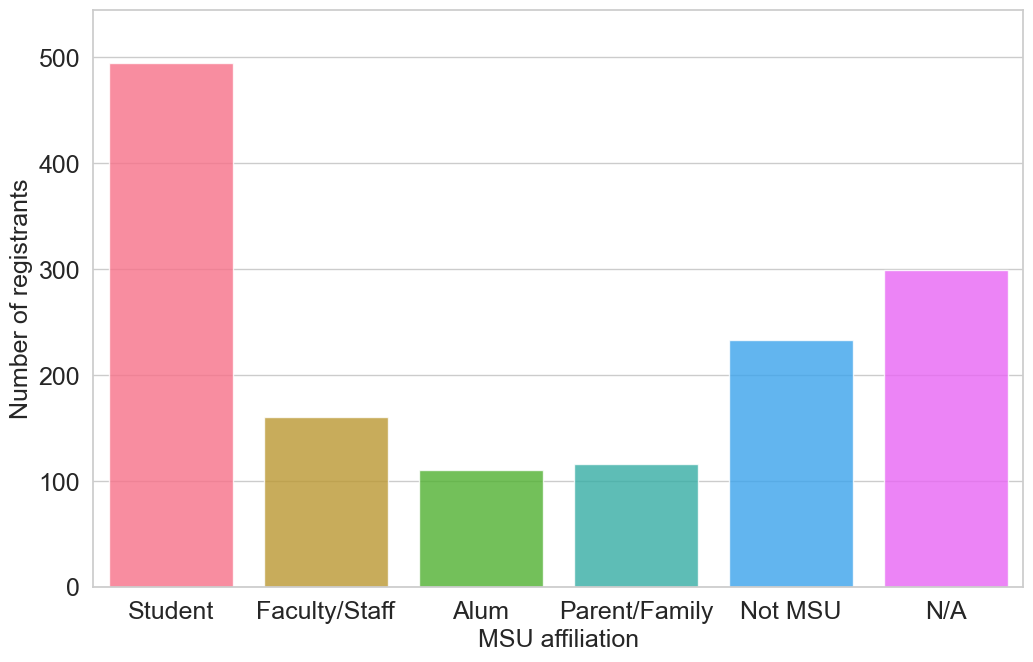

In [44]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(12,7.5))
sns.set_palette("husl")
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Preregistered', palette='husl', 
                  hue='MSU affiliation', estimator=sum, saturation=1, alpha=0.8, err_kws={'linewidth': 0})
ax.set(xlabel="MSU affiliation", ylabel="Number of registrants")
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/pre-reg_affil_bar.png", bbox_inches='tight')
plt.show()

In [45]:
print("\tAttendees by MSU affiliation:")
display(affil_gb['Attended'].sum())

	Attendees by MSU affiliation:


MSU affiliation
Student          281
Faculty/Staff     92
Alum              62
Parent/Family     42
Not MSU           99
N/A              191
Name: Attended, dtype: object

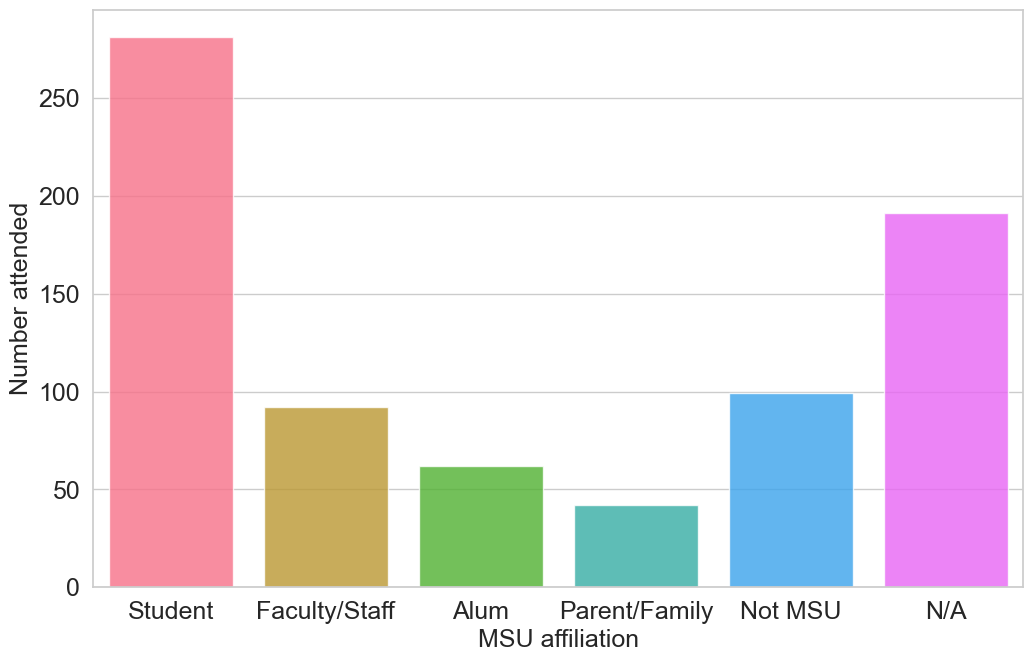

In [46]:
fig, ax = plt.subplots(figsize=(12,7.5))
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Attended', palette='husl', 
                  hue='MSU affiliation', estimator='sum', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="MSU affiliation", ylabel="Number attended")
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/attend_affil_bar.png", bbox_inches='tight')
plt.show()

In [47]:
display(affil_gb['Percentage'].mean())

MSU affiliation
Student          0.565388
Faculty/Staff    0.508123
Alum             0.526268
Parent/Family    0.358255
Not MSU          0.421227
N/A              0.629026
Name: Percentage, dtype: object

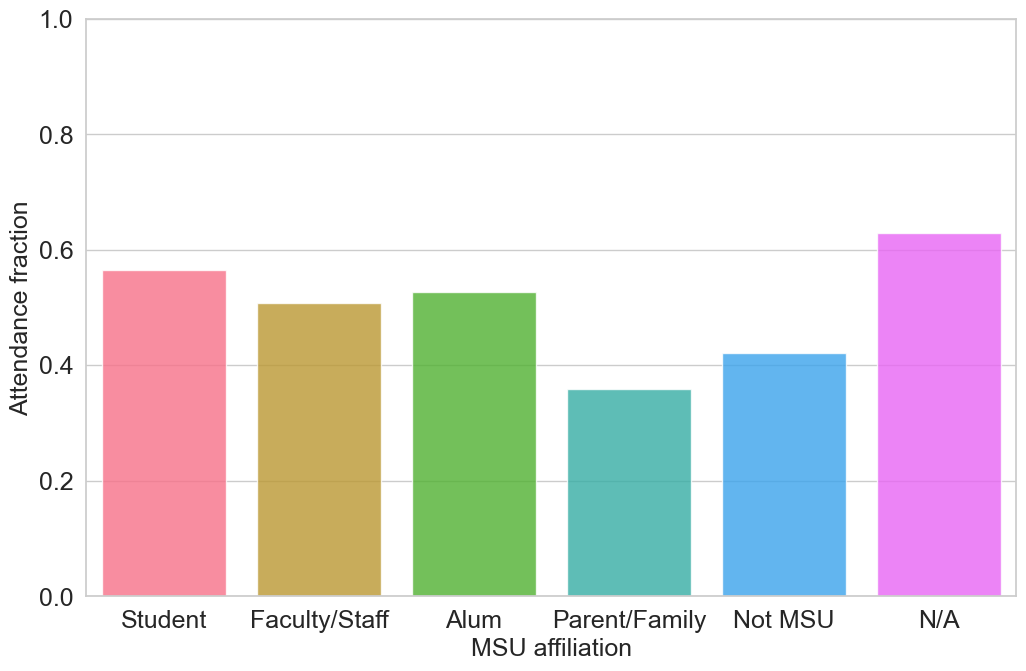

In [48]:
fig, ax = plt.subplots(figsize=(12,7.5))
fig = sns.barplot(data=reg_by_name, x='MSU affiliation', y='Percentage', palette='husl', 
                  hue='MSU affiliation', saturation=1, alpha=0.8, errorbar=None)
ax.set(xlabel="MSU affiliation", ylabel="Attendance fraction", ylim=(0,1))
ax.get_legend().remove()
ax.tick_params(axis='both', which='major', labelsize=18)
ax.xaxis.label.set_size(18)
ax.yaxis.label.set_size(18)
fig.figure.savefig(q_dir+"/percent_affil_bar.png", bbox_inches='tight')
plt.show()